# LASSA SEROPREVALENCE MACHINE LEARNING
## SECTION 5: EXPLAINABILITY (CAUTION) + PROBABILITY CALIBRATION (CRITICAL)

### What this notebook does (end-to-end)
**Phase 6: Explainability + Feature Importance (with caution)**
- XGBoost feature importance (gain)
- SHAP summary plot (optional)
- Clear warning: **interpretation is unstable because positives are too few (3 total)**

**Phase 7: Calibration (very important)**
- Build **OOF predicted probabilities** via 3-fold Stratified CV
- Calibrate OOF probabilities using:
  1) **Platt scaling** (sigmoid; LogisticRegression)
  2) **Isotonic regression** (optional; risky with tiny positives)
- Evaluate calibration (Brier score, calibration curve)
- Re-run threshold sweep and save **new calibrated thresholds**
- Train final XGB on full data + fit calibration model on OOF predictions
- Save artifacts to `models/` and `results/`

### Critical reality
- You have **3 positives**. Any interpretation is **noisy**.
- SHAP and feature importance can still be generated, but must be labeled as **exploratory**.
- Calibration is important because you are thresholding probabilities.


---
## CELL 5.0: IMPORTS + FOLDER SETUP + GLOBAL SETTINGS

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

print("\n" + "="*100)
print("SECTION 5: EXPLAINABILITY + CALIBRATION")
print("="*100)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Path("models").mkdir(parents=True, exist_ok=True)
Path("results/plots").mkdir(parents=True, exist_ok=True)
Path("results/reports").mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 7),
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Run timestamp:", RUN_TS)



SECTION 5: EXPLAINABILITY + CALIBRATION
Run timestamp: 20260331_191543


---
## CELL 5.1: LOAD DATA + CLEAN + TARGET MAP (same as Section 4)

Notes:
- Adjust `DATA_PATH` to match your project.
- We drop `Full_Name`, `Patient_ID`.
- We also drop high-cardinality columns `Town/City`, `Occupation` (same as Section 4 direction).


In [3]:
# IMPORTANT: set this to the same file you used in Section 3/4
# In your Section 3 you used: data/embeddings/data/LASV_Master_Data!.csv
# In your pasted Section 4 snippet you used: data/LASV_Master_Data!.csv
# Pick the correct one for your folder.
DATA_PATH = "data/LASV_Master_Data!.csv"
TARGET_COL = "lab_results.PCR_Results"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Missing dataset at: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# strip whitespace in all object cols
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# drop ID/leakage cols
df = df.drop(columns=["Full_Name", "Patient_ID"], errors="ignore")

# map target
mapping = {"No Kb (Negative)": 0, "320Kb (Positive)": 1}
y = df[TARGET_COL].map(mapping)
if y.isna().any():
    bad = df.loc[y.isna(), TARGET_COL].unique().tolist()
    raise ValueError(f"Unmapped target values found: {bad}")
y = y.astype(int).values

X = df.drop(columns=[TARGET_COL])

# drop high-cardinality (final direction)
DROP_COLS = [c for c in ["Town/City", "Occupation"] if c in X.columns]
X_drop = X.drop(columns=DROP_COLS, errors="ignore").copy()

print("X_drop shape:", X_drop.shape)
print("Dropped:", DROP_COLS)
print("Positives:", int((y==1).sum()), "Negatives:", int((y==0).sum()))


X_drop shape: (250, 41)
Dropped: ['Town/City', 'Occupation']
Positives: 3 Negatives: 247


---
## CELL 5.2: BUILD PREPROCESS PIPELINE (same as Section 4)

In [4]:
num_cols = X_drop.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_drop.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols))


Numeric: 3 Categorical: 38


---
## CELL 5.3: MODEL CONFIG (same family as Section 4)

We will use a stable default setup and compute `scale_pos_weight` per fold.


In [5]:
def make_xgb(scale_pos_weight: float):
    return xgb.XGBClassifier(
        n_estimators=2500,
        learning_rate=0.02,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        min_child_weight=2,
        gamma=0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )


---
## CELL 5.4: OOF CV (3-fold) to produce UNCALIBRATED OOF probabilities

This is the correct input for calibration.


In [6]:
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

oof_proba_raw = np.zeros(len(X_drop), dtype=float)
fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf3.split(X_drop, y), 1):
    X_tr, X_va = X_drop.iloc[tr_idx], X_drop.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    neg = int((y_tr == 0).sum())
    pos = int((y_tr == 1).sum())
    spw = neg / max(pos, 1)

    Xt_tr = preprocess.fit_transform(X_tr)
    Xt_va = preprocess.transform(X_va)

    model = make_xgb(scale_pos_weight=spw)
    model.fit(Xt_tr, y_tr, eval_set=[(Xt_va, y_va)], verbose=False)

    proba = model.predict_proba(Xt_va)[:, 1]
    oof_proba_raw[va_idx] = proba

    fold_rows.append({
        "fold": fold,
        "val_size": int(len(va_idx)),
        "val_pos": int((y_va==1).sum()),
        "scale_pos_weight": float(spw),
        "pr_auc": float(average_precision_score(y_va, proba)) if len(np.unique(y_va)) > 1 else np.nan,
        "roc_auc": float(roc_auc_score(y_va, proba)) if len(np.unique(y_va)) > 1 else np.nan
    })

fold_df = pd.DataFrame(fold_rows)

oof_pr_auc = average_precision_score(y, oof_proba_raw)
oof_roc_auc = roc_auc_score(y, oof_proba_raw)
oof_brier = brier_score_loss(y, oof_proba_raw)

pd.DataFrame({"y": y, "oof_proba_raw": oof_proba_raw}).to_csv(
    "results/reports/section5_oof_raw_predictions.csv", index=False
)
fold_df.to_csv("results/reports/section5_oof_raw_folds.csv", index=False)

print("\nOOF RAW PR-AUC:", oof_pr_auc)
print("OOF RAW ROC-AUC:", oof_roc_auc)
print("OOF RAW Brier:", oof_brier)
print("Saved:")
print("  results/reports/section5_oof_raw_predictions.csv")
print("  results/reports/section5_oof_raw_folds.csv")
display(fold_df)



OOF RAW PR-AUC: 0.05740740740740741
OOF RAW ROC-AUC: 0.7786774628879891
OOF RAW Brier: 0.019595836663814075
Saved:
  results/reports/section5_oof_raw_predictions.csv
  results/reports/section5_oof_raw_folds.csv


,fold,val_size,val_pos,scale_pos_weight,pr_auc,roc_auc
0,1,84,1,82.0,0.030303,0.626506
1,2,83,1,82.5,0.040000,0.707317
2,3,83,1,82.5,0.333333,0.975610


---
## CELL 5.5: CALIBRATION MODELS FIT ON OOF (Platt + Isotonic)

Important:
- We fit calibrators on **OOF raw probabilities** vs `y`.
- This avoids training-set leakage.
- **Isotonic** can overfit badly with 3 positives. We'll still compute it but label caution.


In [7]:
# Platt scaling (sigmoid) = LogisticRegression on single feature: raw_prob
X_cal = oof_proba_raw.reshape(-1, 1)

platt = LogisticRegression(solver="lbfgs", max_iter=2000)
platt.fit(X_cal, y)
oof_proba_platt = platt.predict_proba(X_cal)[:, 1]

# Isotonic calibration (risky with tiny positives)
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oof_proba_raw, y)
oof_proba_iso = iso.transform(oof_proba_raw)

metrics = {
    "raw": {
        "pr_auc": float(average_precision_score(y, oof_proba_raw)),
        "roc_auc": float(roc_auc_score(y, oof_proba_raw)),
        "brier": float(brier_score_loss(y, oof_proba_raw)),
    },
    "platt": {
        "pr_auc": float(average_precision_score(y, oof_proba_platt)),
        "roc_auc": float(roc_auc_score(y, oof_proba_platt)),
        "brier": float(brier_score_loss(y, oof_proba_platt)),
    },
    "isotonic": {
        "pr_auc": float(average_precision_score(y, oof_proba_iso)),
        "roc_auc": float(roc_auc_score(y, oof_proba_iso)),
        "brier": float(brier_score_loss(y, oof_proba_iso)),
    }
}

with open("results/reports/section5_calibration_metrics.json", "w") as f:
    json.dump({
        "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "notes": {
            "warning": "Only 3 positives: calibration + importance estimates are unstable. Treat as exploratory.",
            "isotonic_warning": "Isotonic regression can severely overfit with tiny positives; use Platt as default."
        },
        "metrics": metrics
    }, f, indent=2)

pd.DataFrame({
    "y": y,
    "raw": oof_proba_raw,
    "platt": oof_proba_platt,
    "isotonic": oof_proba_iso
}).to_csv("results/reports/section5_oof_calibrated_predictions.csv", index=False)

print(json.dumps(metrics, indent=2))
print("Saved:")
print("  results/reports/section5_calibration_metrics.json")
print("  results/reports/section5_oof_calibrated_predictions.csv")


{
  "raw": {
    "pr_auc": 0.05740740740740741,
    "roc_auc": 0.7786774628879891,
    "brier": 0.019595836663814075
  },
  "platt": {
    "pr_auc": 0.05740740740740741,
    "roc_auc": 0.7786774628879891,
    "brier": 0.011855415386574177
  },
  "isotonic": {
    "pr_auc": 0.05925925925925926,
    "roc_auc": 0.8663967611336032,
    "brier": 0.011358024691358022
  }
}
Saved:
  results/reports/section5_calibration_metrics.json
  results/reports/section5_oof_calibrated_predictions.csv


---
## CELL 5.6: CALIBRATION CURVES (Reliability Diagrams) + Save Plots

We plot calibration curves for raw vs platt vs isotonic.
Because positives are extremely few, the curve is noisy; still useful to see direction.


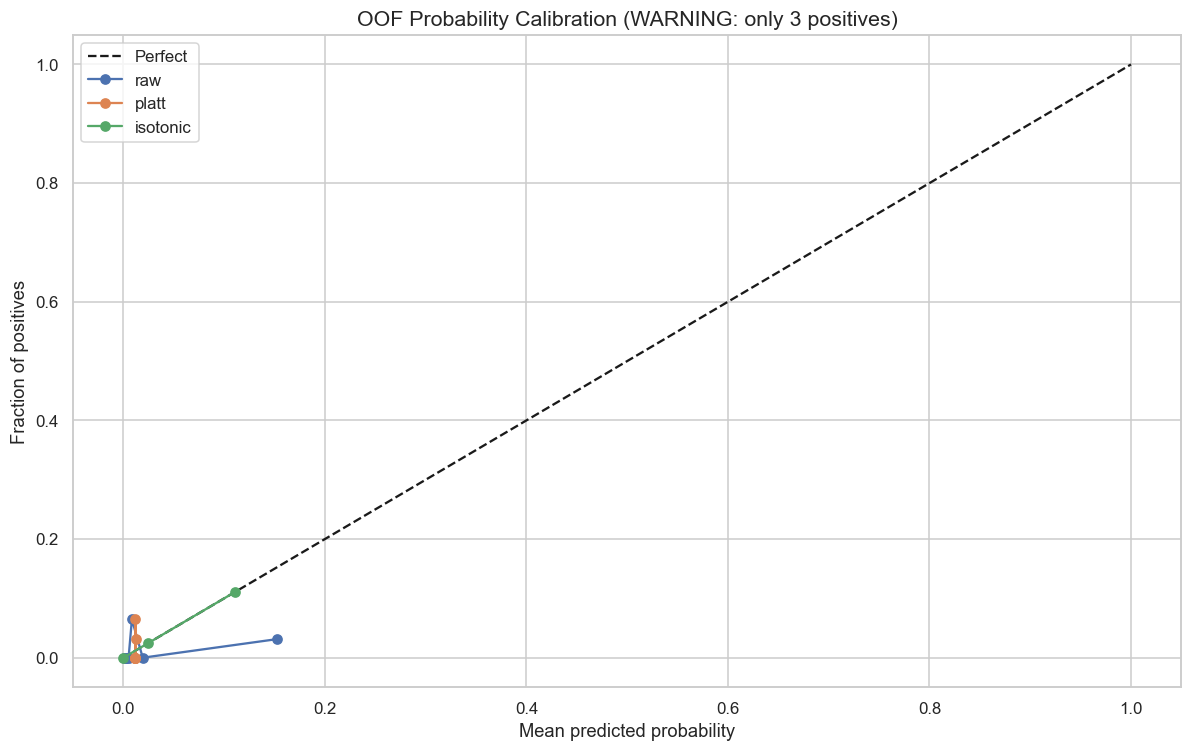

✓ Saved: results/plots/section5_calibration_curve_oof.png


In [8]:
def plot_calibration(y_true, prob_dict, n_bins=10, title="Calibration Curve (OOF)"):
    plt.figure()
    plt.plot([0,1],[0,1], "k--", label="Perfect")
    for name, p in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", label=name)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title + " (WARNING: only 3 positives)")
    plt.legend()
    plt.tight_layout()

plot_calibration(
    y,
    {"raw": oof_proba_raw, "platt": oof_proba_platt, "isotonic": oof_proba_iso},
    n_bins=8,
    title="OOF Probability Calibration"
)
plt.savefig("results/plots/section5_calibration_curve_oof.png")
plt.show()
print("✓ Saved: results/plots/section5_calibration_curve_oof.png")


---
## CELL 5.7: THRESHOLD SWEEP (RAW vs PLATT vs ISOTONIC) + Save

We repeat the threshold analysis using calibrated probabilities.
This is what you want if you're going to operationalize thresholds.


In [9]:
def threshold_sweep(y_true, proba, n=500):
    thresholds = np.linspace(0.001, 0.5, n)
    rows = []
    for t in thresholds:
        y_hat = (proba >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "f1": float(f1_score(y_true, y_hat, zero_division=0)),
            "precision": float(precision_score(y_true, y_hat, zero_division=0)),
            "recall": float(recall_score(y_true, y_hat, zero_division=0)),
            "predicted_positives": int(y_hat.sum())
        })
    df = pd.DataFrame(rows)
    best_recall = df.sort_values(["recall", "precision"], ascending=False).iloc[0]
    best_f1 = df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    cand = df[df["predicted_positives"] > 0]
    best_precision = cand.sort_values(["precision", "recall", "f1"], ascending=False).iloc[0]
    choices = {
        "screening_high_recall": best_recall.to_dict(),
        "balanced_best_f1": best_f1.to_dict(),
        "confirmatory_high_precision": best_precision.to_dict()
    }
    return df, choices

sweep_raw, choices_raw = threshold_sweep(y, oof_proba_raw)
sweep_platt, choices_platt = threshold_sweep(y, oof_proba_platt)
sweep_iso, choices_iso = threshold_sweep(y, oof_proba_iso)

sweep_raw.to_csv("results/reports/section5_threshold_sweep_raw.csv", index=False)
sweep_platt.to_csv("results/reports/section5_threshold_sweep_platt.csv", index=False)
sweep_iso.to_csv("results/reports/section5_threshold_sweep_isotonic.csv", index=False)

threshold_summary = {
    "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "warning": "Only 3 positives: thresholds are unstable; treat as exploratory.",
    "raw": choices_raw,
    "platt": choices_platt,
    "isotonic": choices_iso
}
with open("results/reports/section5_threshold_choices_calibrated.json", "w") as f:
    json.dump(threshold_summary, f, indent=2)

print("RAW choices:")
print(json.dumps(choices_raw, indent=2))
print("\nPLATT choices (recommended default):")
print(json.dumps(choices_platt, indent=2))
print("\nISOTONIC choices (RISKY with 3 positives):")
print(json.dumps(choices_iso, indent=2))
print("\nSaved:")
print("  results/reports/section5_threshold_choices_calibrated.json")


RAW choices:
{
  "screening_high_recall": {
    "threshold": 0.006,
    "f1": 0.0594059405940594,
    "precision": 0.030612244897959183,
    "recall": 1.0,
    "predicted_positives": 98.0
  },
  "balanced_best_f1": {
    "threshold": 0.113,
    "f1": 0.16666666666666666,
    "precision": 0.1111111111111111,
    "recall": 0.3333333333333333,
    "predicted_positives": 9.0
  },
  "confirmatory_high_precision": {
    "threshold": 0.113,
    "f1": 0.16666666666666666,
    "precision": 0.1111111111111111,
    "recall": 0.3333333333333333,
    "predicted_positives": 9.0
  }
}

PLATT choices (recommended default):
{
  "screening_high_recall": {
    "threshold": 0.001,
    "f1": 0.023715415019762844,
    "precision": 0.012,
    "recall": 1.0,
    "predicted_positives": 250.0
  },
  "balanced_best_f1": {
    "threshold": 0.012,
    "f1": 0.13333333333333333,
    "precision": 0.08333333333333333,
    "recall": 0.3333333333333333,
    "predicted_positives": 12.0
  },
  "confirmatory_high_precisio

---
## CELL 5.8: Plot Threshold Curves (F1/Precision/Recall) for RAW vs PLATT

We focus on Platt because it's usually safer with tiny positives.


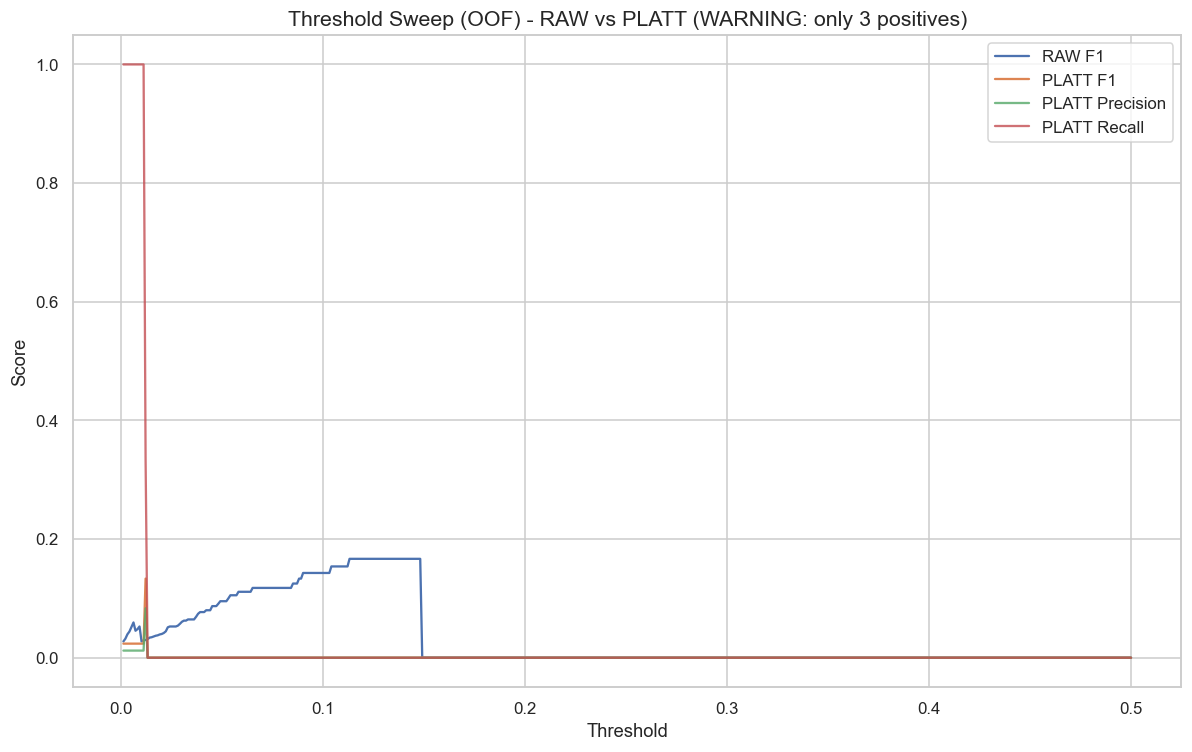

✓ Saved: results/plots/section5_threshold_sweep_raw_vs_platt.png


In [10]:
plt.figure()
plt.plot(sweep_raw["threshold"], sweep_raw["f1"], label="RAW F1")
plt.plot(sweep_platt["threshold"], sweep_platt["f1"], label="PLATT F1")
plt.plot(sweep_platt["threshold"], sweep_platt["precision"], label="PLATT Precision", alpha=0.8)
plt.plot(sweep_platt["threshold"], sweep_platt["recall"], label="PLATT Recall", alpha=0.8)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep (OOF) - RAW vs PLATT (WARNING: only 3 positives)")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/section5_threshold_sweep_raw_vs_platt.png")
plt.show()
print("✓ Saved: results/plots/section5_threshold_sweep_raw_vs_platt.png")


---
## CELL 5.9: Train FINAL XGB on FULL DATA + Save Pipeline

Then we save:
- preprocess transformer
- final XGB model
- Platt calibrator (recommended)

At inference time:
1) preprocess.transform(X)
2) raw_proba = xgb.predict_proba(Xt)[:,1]
3) calibrated_proba = platt.predict_proba(raw_proba.reshape(-1,1))[:,1]
4) apply chosen threshold


In [11]:
neg_full = int((y == 0).sum())
pos_full = int((y == 1).sum())
spw_full = neg_full / max(pos_full, 1)

Xt_full = preprocess.fit_transform(X_drop)
xgb_final = make_xgb(scale_pos_weight=spw_full)
xgb_final.fit(Xt_full, y, verbose=False)

# Save artifacts
joblib.dump(preprocess, "models/section5_preprocess_drop.joblib")
joblib.dump(xgb_final, "models/section5_xgb_model.joblib")
joblib.dump(platt, "models/section5_platt_calibrator.joblib")

# (Optional) save xgb JSON
xgb_final.save_model("models/section5_xgb_model.json")

print("✓ Saved:")
print("  models/section5_preprocess_drop.joblib")
print("  models/section5_xgb_model.joblib")
print("  models/section5_platt_calibrator.joblib")
print("  models/section5_xgb_model.json")


✓ Saved:
  models/section5_preprocess_drop.joblib
  models/section5_xgb_model.joblib
  models/section5_platt_calibrator.joblib
  models/section5_xgb_model.json


---
## CELL 5.10: Feature Importance (Gain) + Save Plot (CAUTION)

WARNING:
- With only 3 positives, importance rankings are **unstable**.
- Treat this as exploratory.


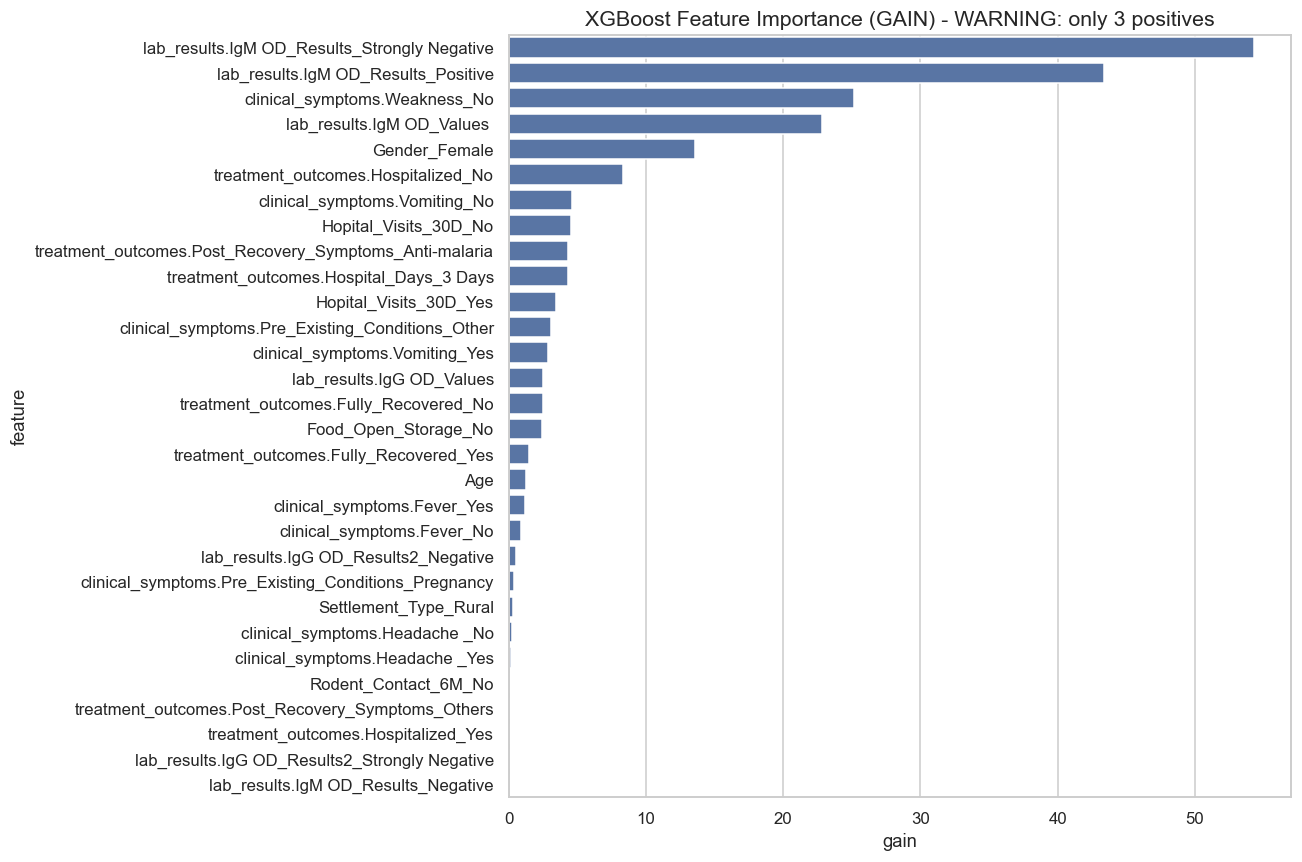

Top features:


,feature,gain
29,lab_results.IgM OD_Results_Strongly Negative,54.319866
28,lab_results.IgM OD_Results_Positive,43.358646
14,clinical_symptoms.Weakness_No,25.201532
1,lab_results.IgM OD_Values,22.804106
3,Gender_Female,13.577078
19,treatment_outcomes.Hospitalized_No,8.304998
15,clinical_symptoms.Vomiting_No,4.603858
8,Hopital_Visits_30D_No,4.573567
24,treatment_outcomes.Post_Recovery_Symptoms_Anti...,4.362064
21,treatment_outcomes.Hospital_Days_3 Days,4.313799


✓ Saved:
  results/reports/section5_xgb_feature_importance_gain.csv
  results/plots/section5_xgb_feature_importance_gain_top30.png


In [12]:
feature_names = preprocess.get_feature_names_out()
booster = xgb_final.get_booster()

# gain importance for xgb (keys are f0,f1,...)
gain_dict = booster.get_score(importance_type="gain")

# map f-index -> feature name
rows = []
for k, v in gain_dict.items():
    if k.startswith("f"):
        idx = int(k[1:])
        if idx < len(feature_names):
            rows.append({"feature": feature_names[idx], "gain": float(v)})

imp_df = pd.DataFrame(rows).sort_values("gain", ascending=False)
imp_df.to_csv("results/reports/section5_xgb_feature_importance_gain.csv", index=False)

topn = 30 if len(imp_df) > 30 else len(imp_df)
plt.figure(figsize=(12, 8))
sns.barplot(data=imp_df.head(topn), x="gain", y="feature")
plt.title("XGBoost Feature Importance (GAIN) - WARNING: only 3 positives")
plt.tight_layout()
plt.savefig("results/plots/section5_xgb_feature_importance_gain_top30.png")
plt.show()

print("Top features:")
display(imp_df.head(15))
print("✓ Saved:")
print("  results/reports/section5_xgb_feature_importance_gain.csv")
print("  results/plots/section5_xgb_feature_importance_gain_top30.png")


---
## CELL 5.11: SHAP Summary Plot (OPTIONAL) + Save (CAUTION)

This requires `shap` installed:
```bash
pip install shap
```

WARNING:
- With 3 positives, SHAP explanations are **unstable**.
- Use for exploratory insight only.


/Users/user/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/st/yst5x36n4636qhvdhhx2gb7m0000gn/T/ipykernel_76975/1399151597.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=Xt, feature_names=feature_names, plot_type="bar", show=False)


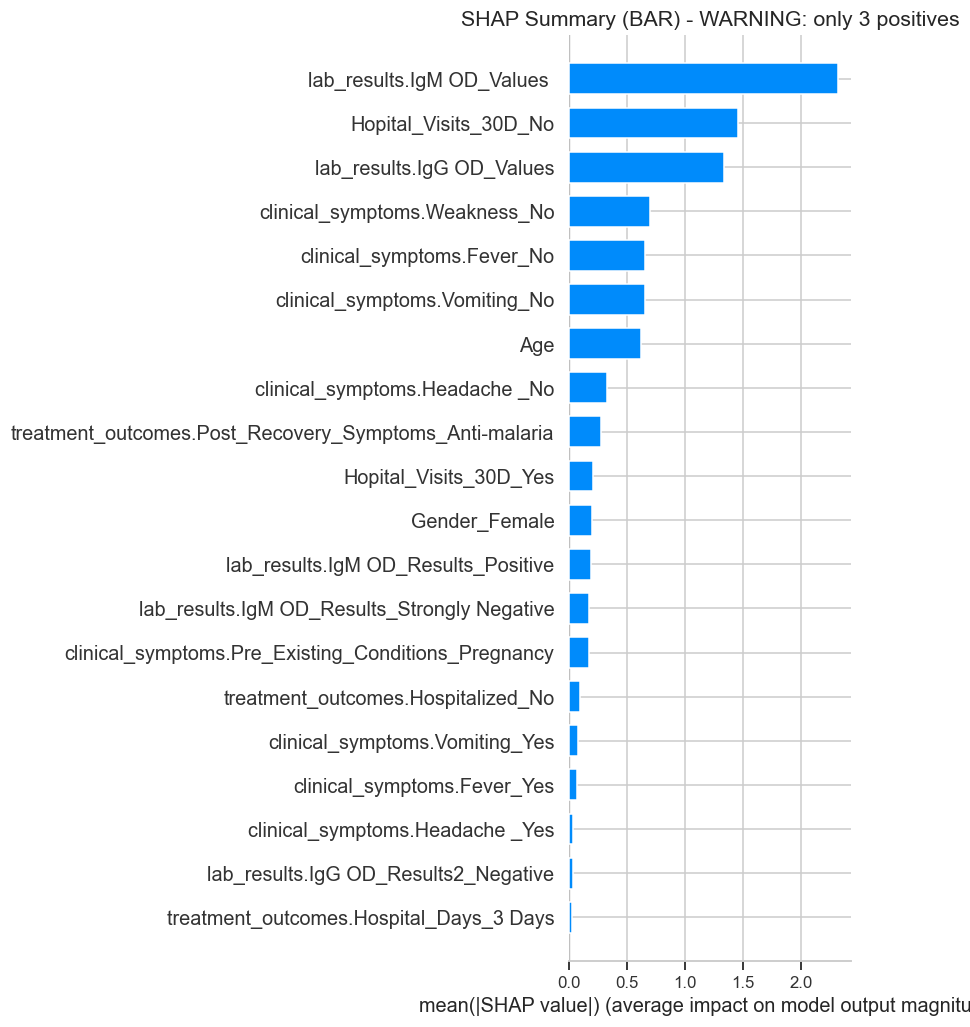

/var/folders/st/yst5x36n4636qhvdhhx2gb7m0000gn/T/ipykernel_76975/1399151597.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=Xt, feature_names=feature_names, show=False)


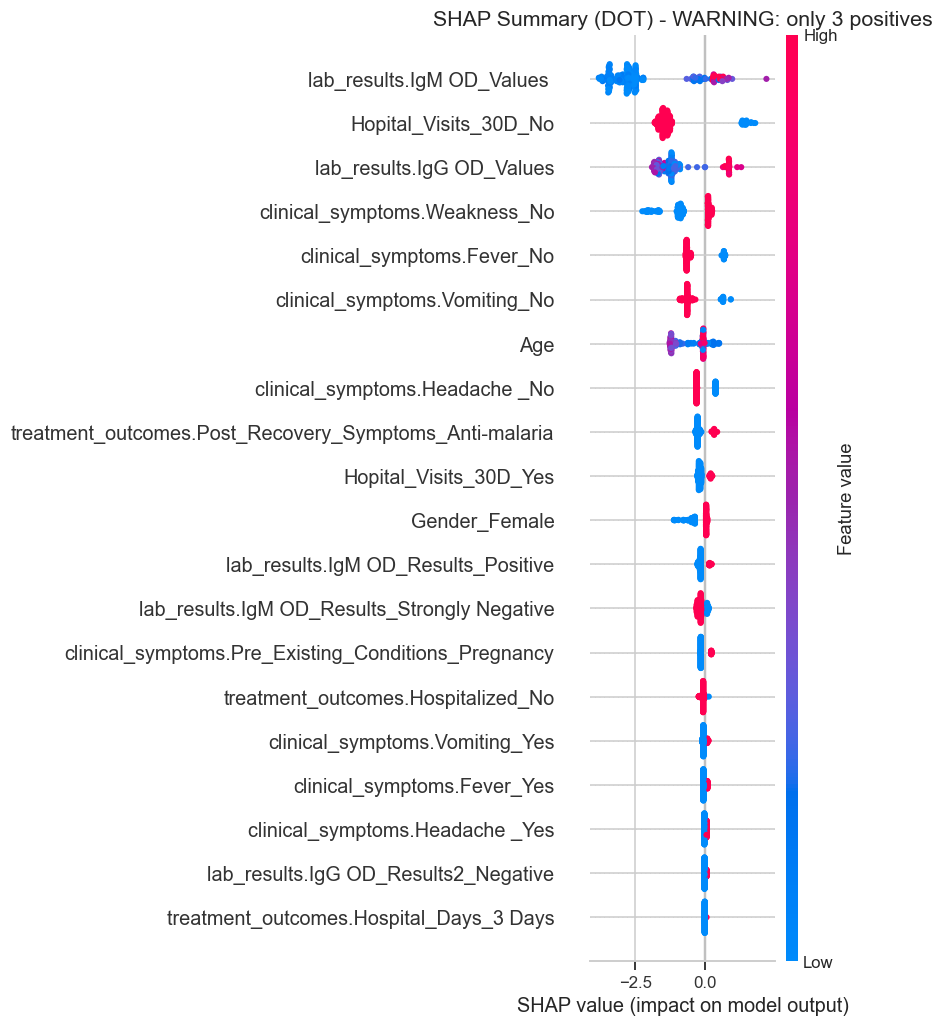

✓ Saved:
  results/plots/section5_shap_summary_bar.png
  results/plots/section5_shap_summary_dot.png


In [13]:
try:
    import shap
    
    # Sample a smaller background if needed
    Xt = Xt_full
    
    explainer = shap.TreeExplainer(xgb_final)
    shap_values = explainer.shap_values(Xt)
    
    # SHAP summary plot (bar)
    plt.figure()
    shap.summary_plot(shap_values, features=Xt, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Summary (BAR) - WARNING: only 3 positives")
    plt.tight_layout()
    plt.savefig("results/plots/section5_shap_summary_bar.png")
    plt.show()
    
    # SHAP summary dot plot
    shap.summary_plot(shap_values, features=Xt, feature_names=feature_names, show=False)
    plt.title("SHAP Summary (DOT) - WARNING: only 3 positives")
    plt.tight_layout()
    plt.savefig("results/plots/section5_shap_summary_dot.png")
    plt.show()
    
    print("✓ Saved:")
    print("  results/plots/section5_shap_summary_bar.png")
    print("  results/plots/section5_shap_summary_dot.png")

except Exception as e:
    print("SHAP not available or failed. Install shap or check environment.")
    print("Error:", str(e))


---
## CELL 5.12: Inference Helper (Raw -> Platt Calibrated -> Threshold)

This cell shows exactly how you will predict on new data.


In [14]:
def predict_calibrated(X_new: pd.DataFrame, preprocess, xgb_model, platt_calibrator, threshold: float):
    Xt = preprocess.transform(X_new)
    raw = xgb_model.predict_proba(Xt)[:, 1]
    cal = platt_calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
    pred = (cal >= threshold).astype(int)
    return raw, cal, pred

print("Helper ready: predict_calibrated(X_new, preprocess, xgb_final, platt, threshold)")
print("Tip: use threshold from results/reports/section5_threshold_choices_calibrated.json under 'platt'")


Helper ready: predict_calibrated(X_new, preprocess, xgb_final, platt, threshold)
Tip: use threshold from results/reports/section5_threshold_choices_calibrated.json under 'platt'
